# RAG시스템 구축을 위한 제안요청서(RFP) 메타데이터 EDA

- 제안요청서 RFP 기반의 Q&A 서비스, '입찰메이트'를 구현에 앞서
메타데이터를 탐색하여 데이터의 특징을 파악해봅니다.

## 본 프로젝트 개요
- data_list.csv 파일의 메타데이터를 확인한다.


1. 데이터 기초 탐색

In [1]:
import pandas as pd

# 데이터 로드
metadata = pd.read_csv("/Users/apple/Team2-RAG-Project/data/raw/data_list.csv")

# 데이터 확인
metadata.head()

,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...
3,20240430918,0.0,도시계획위원회 통합관리시스템 구축용역,150000000.0,인천광역시,2024-04-18 16:26:32,2024-05-02 10:00:00,2024-05-09 16:00:00,- 사업명: 도시계획위원회 통합관리시스템 구축 용역\n- 용역개요: 도시계획위원회와...,hwp,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp,\r\n \r\n \r\n도시계획위원회 통합관리시스템 구축\r\n제 안 요 청...
4,20240430896,0.0,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),900000000.0,경상북도 봉화군,2024-04-18 16:33:28,2024-04-26 09:00:00,2024-04-30 17:00:00,- 사업명: 봉화군 재난통합관리시스템 고도화 사업\n- 사업개요: 공동수급(공동이행...,hwp,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp,\r\n \r\n \r\n제안요청서\r\n \r\n사 업 명\r\n봉화...


#### 분석

- 공고 번호: 날짜와 관련되어 보인다.
- 공고 차수: 모든 데이터가 0.0로 보인다.
- 사업명에 "협상", "긴급", "재공고" 같은 키워드를 포함한 파일들이 있다. 
- 사업 금액 분포 확인.
- 발주 기관 분포 확인. 범주화 할 수 있는가, 한국단위/ 지역단위/ 대학교 등등
- 공개 일자
- 입찰 참여 시작일
- 입찰 참여 마감일
- 사업 요약, 사업 개요/ 사업명/ 과업명
- 텍스트: 제목, 목차, 추가적인 정보로 구성

#### 확인 요소
- 사업명은 파일 이름과 일치하는 가 파일 데이터 분석 때 확인.
- 파일명은 파일 이름과 일치하는 가, 모든 파일 이름과 일치하는가 - 파일 파싱 후 확인
- 공고 차수, 모든 데이터가 0.0인지 확인, 재공고를 의미하는가.
- 사업 금액 분포 확인.
- 발주 기관 분포 확인. 범주화 할 수 있는가, 한국단위/ 지역단위/ 대학교 등등
- 사업명에 "협상", "긴급", "재공고" 같은 키워드를 활용할 수 있는가.
- 메타데이터의 사업 요약, 텍스트 같은 정보는 어디에 활용해야 되는가.

In [3]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   공고 번호      82 non-null     object 
 1   공고 차수      82 non-null     float64
 2   사업명        100 non-null    object 
 3   사업 금액      99 non-null     float64
 4   발주 기관      100 non-null    object 
 5   공개 일자      100 non-null    object 
 6   입찰 참여 시작일  74 non-null     object 
 7   입찰 참여 마감일  92 non-null     object 
 8   사업 요약      100 non-null    object 
 9   파일형식       100 non-null    object 
 10  파일명        100 non-null    object 
 11  텍스트        100 non-null    object 
dtypes: float64(2), object(10)
memory usage: 9.5+ KB


- 공고 번호, 공고 차수, 사업 금액, 입찰 참여 시작일, 입찰 참여 마감일에 결측치 존재.
- Q. 공고 차수는 모두 0인가. 확인 후. 컬럼을 제거해도 되는가?
- 공고 차수와 사업 금액을 제외한 나머지 컬럼은 모두 object 타입 -> 날짜는 datetime으로 변환해야 하는가.

In [5]:
metadata.describe()

,공고 차수,사업 금액
count,82.000000,9.900000e+01
mean,0.097561,6.906720e+08
std,0.372173,1.966691e+09
min,0.000000,0.000000e+00
25%,0.000000,7.000000e+07
50%,0.000000,1.727000e+08
75%,0.000000,4.064889e+08
max,2.000000,1.410701e+10


#### 분석
- 공고 차수에 0이 아닌 2가 존재한다. 
- '재공고'를 의미하는 것으로 추정

#### 확인 요소
- 사업명에 '(재공고)'가 포함된 파일과 일치하는 지 확인.
- 사업금액 그래프로 이해가 가도록 확인.

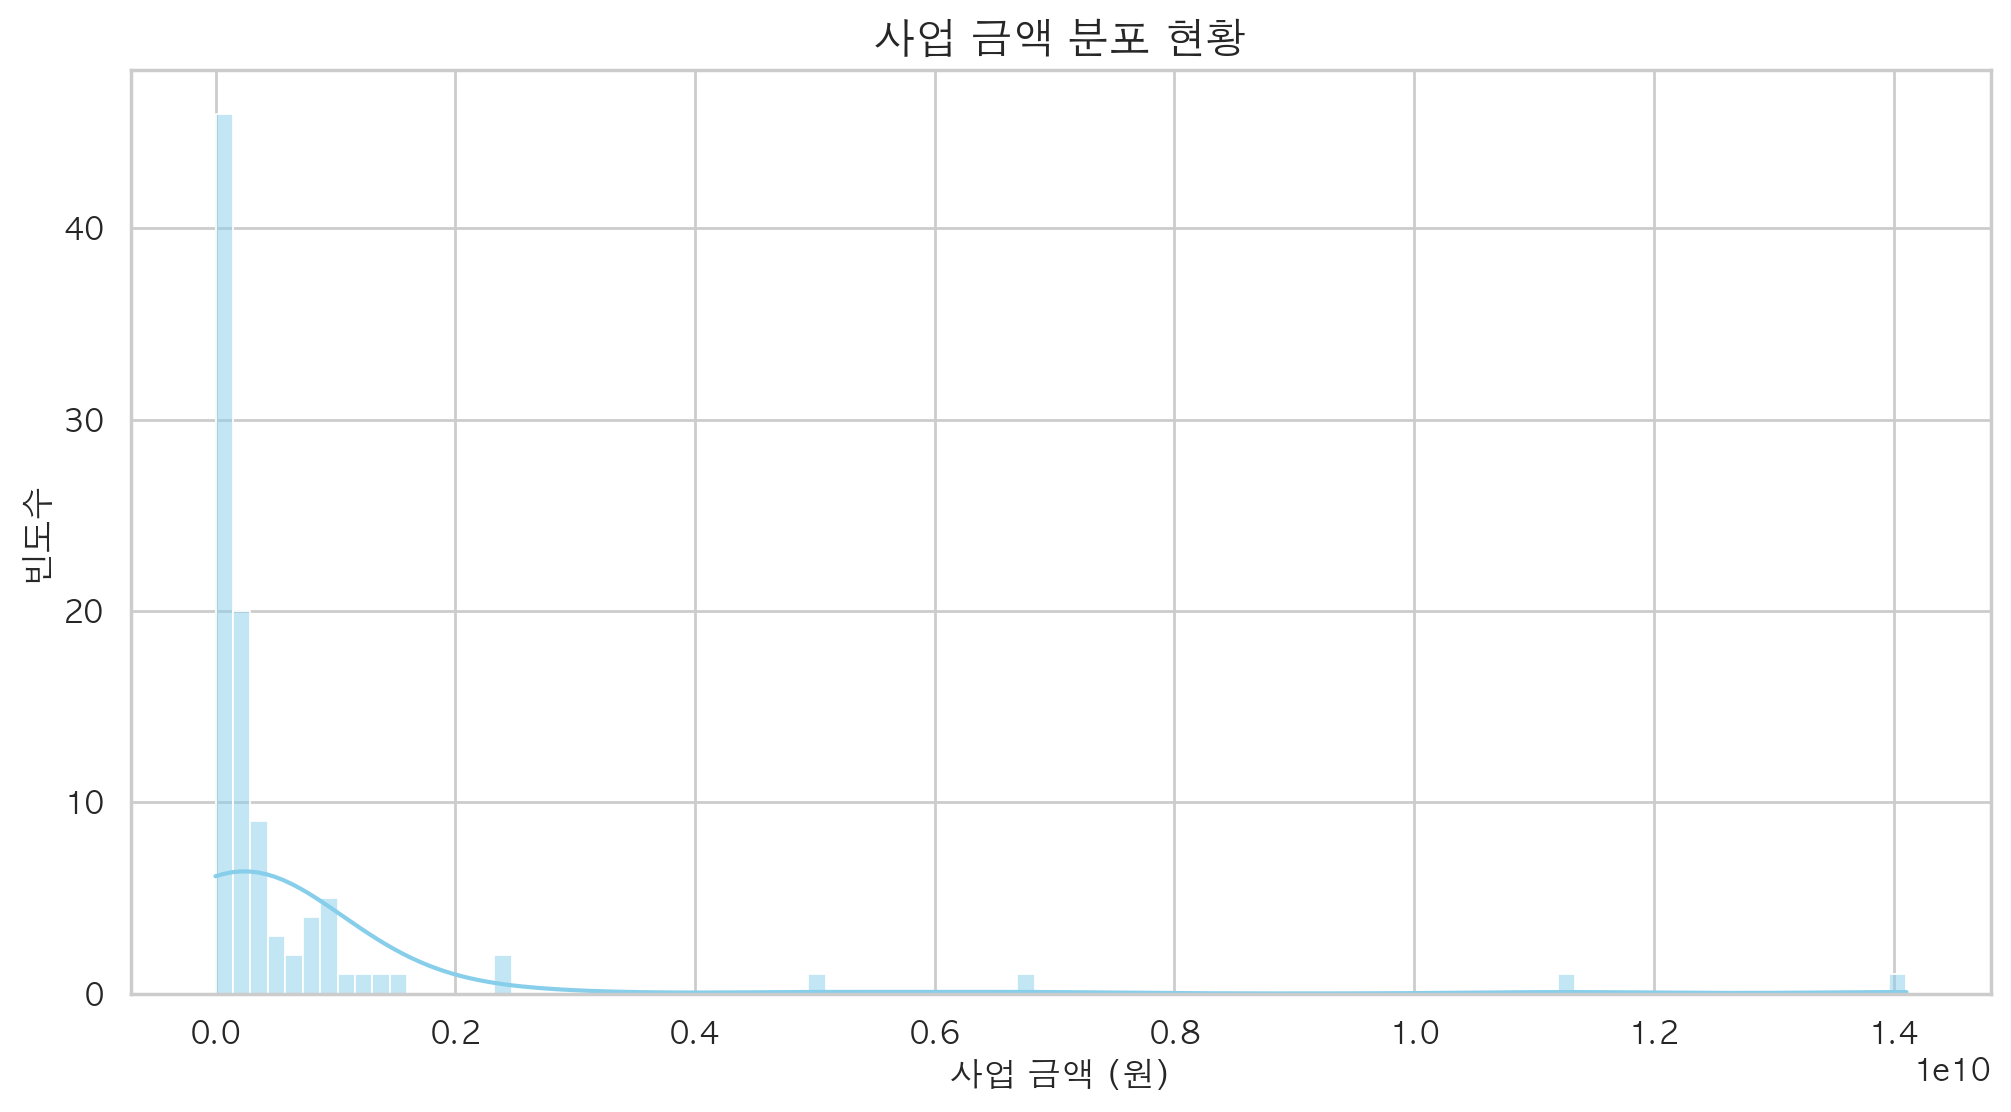

In [4]:
# 사업금액 분포 확인

import matplotlib.pyplot as plt
import seaborn as sns

# 맥 전용 한글 폰트 설정 (AppleGothic)
plt.rcParams['font.family'] = 'AppleGothic'

# 그래프에서 마이너스 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# Seaborn에도 한글 폰트 적용 (기본 테마 설정 시 폰트 재지정 필요)
sns.set_theme(style="whitegrid", font="AppleGothic")

# (옵션) 해상도 높이기 - 레티나 디스플레이 대응
%config InlineBackend.figure_format = 'retina'

plt.figure(figsize=(12, 6))

# bins는 막대의 개수입니다. 데이터에 따라 조절하세요.
sns.histplot(metadata['사업 금액'], kde=True, color='skyblue')
plt.title('사업 금액 분포 현황', fontsize=15)
plt.xlabel('사업 금액 (원)')
plt.ylabel('빈도수')
plt.show()

### 발주 기관 및 제안요청서 분야 분류

In [ ]:
import re
import unicodedata
import pandas as pd

# 1) 정규화
def norm_org(x: str) -> str:
    s = "" if pd.isna(x) else str(x)
    s = unicodedata.normalize("NFC", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 2) 분류 규칙
def classify_org(name: str):
    s = norm_org(name)

    if not s:
        return "기타", "확인필요", 0.0, "빈값"

    if re.search(r"(대학교|대학병원|캠퍼스)", s):
        return "대학교", "기관단위", 0.95, "대학교 키워드"

    if re.search(r"(특별시|광역시|특별자치도|도청|시청|군청|구청|교육청|시의회|도의회)", s):
        return "지자체", "지방단위", 0.95, "지자체 키워드"

    if re.search(r"(재단법인|\(재\)|재단|협회|조합|센터)", s):
        return "재단/협회", "기관단위", 0.90, "재단/협회 키워드"

    if re.search(r"(공사|공단|진흥원|연구원|공공기관|의료원)", s):
        if re.search(r"(서울|부산|대구|인천|광주|대전|울산|세종|경기|강원|충북|충남|전북|전남|경북|경남|제주)", s):
            return "공기업/공공기관", "지방단위", 0.80, "공공기관 + 지역명"
        return "공기업/공공기관", "전국단위", 0.80, "공공기관 키워드"

    if re.search(r"(부|청|위원회|국가|국립)", s):
        return "중앙정부/국가기관", "전국단위", 0.75, "정부기관 키워드"

    if re.search(r"(\(주\)|주식회사|유한회사)", s):
        return "민간기업", "기관단위", 0.85, "법인 키워드"

    return "기타", "확인필요", 0.30, "규칙 미매칭"

# 3) 데이터 로드
csv_path = "/Users/apple/Team2-RAG-Project/data/raw/data_list.csv"
df = pd.read_csv(csv_path)

# 4) "발주 기관" 컬럼 적용
tmp = df["발주 기관"].apply(classify_org).apply(pd.Series)
tmp.columns = ["기관유형", "범위", "신뢰도", "근거"]

result = pd.concat([df, tmp], axis=1)

# 5) 결과 확인
print("기관유형 분포")
print(result["기관유형"].value_counts(), "\n")

print("범위 분포")
print(result["범위"].value_counts(), "\n")

print("검토 우선(신뢰도 < 0.8)")
display(
    result.loc[result["신뢰도"] < 0.8, ["발주 기관", "기관유형", "범위", "신뢰도", "근거"]]
          .drop_duplicates()
          .sort_values(["신뢰도", "발주 기관"])
)


기관유형 분포
기관유형
공기업/공공기관     32
기타           28
재단/협회        11
지자체           9
대학교           9
중앙정부/국가기관     8
민간기업          3
Name: count, dtype: int64 

범위 분포
범위
전국단위    39
확인필요    28
기관단위    23
지방단위    10
Name: count, dtype: int64 

검토 우선(신뢰도 < 0.8)


,발주 기관,기관유형,범위,신뢰도,근거
10,(사）한국대학스포츠협의회,기타,확인필요,0.30,규칙 미매칭
46,BioIN,기타,확인필요,0.30,규칙 미매칭
26,KOICA 전자조달,기타,확인필요,0.30,규칙 미매칭
75,경기도 안양시,기타,확인필요,0.30,규칙 미매칭
60,경기도 평택시,기타,확인필요,0.30,규칙 미매칭
87,경기도사회서비스원,기타,확인필요,0.30,규칙 미매칭
4,경상북도 봉화군,기타,확인필요,0.30,규칙 미매칭
38,광주과학기술원,기타,확인필요,0.30,규칙 미매칭
9,국방과학연구소,기타,확인필요,0.30,규칙 미매칭
99,나노종합기술원,기타,확인필요,0.30,규칙 미매칭


전체 문서 수: 100


,분야,건수,비율(%)
0,교육,19,19.0
1,과학기술/연구/산업,15,15.0
2,문화/예술/관광/체육,13,13.0
3,안전/재난/치안/국방,12,12.0
4,행정/공공운영/경영,11,11.0
5,농림/수산/식품/환경,10,10.0
6,교통/모빌리티/물류,9,9.0
7,의료/보건/복지,7,7.0
8,금융/보험,3,3.0
9,국제협력/개발,1,1.0


,분야,분야_근거키워드,파일명
39,과학기술/연구/산업,지도정보,서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf
15,과학기술/연구/산업,과학,국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp
18,과학기술/연구/산업,특허,한국발명진흥회 입찰공고_2024년 건설기술에 관한 특허·실용신안 활용실.hwp
0,교육,대학교,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp
1,교육,대학,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp
7,교육,대학교,고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
34,교통/모빌리티/물류,철도,한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp
33,교통/모빌리티/물류,버스,울산광역시_2024년 버스정보시스템 확대 구축 및 기능개선 용역.hwp
16,교통/모빌리티/물류,철도,한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp
26,국제협력/개발,koica,KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp


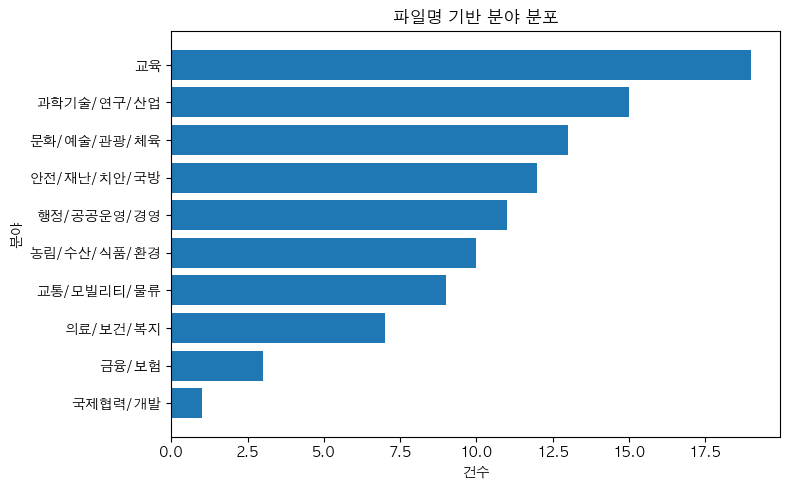

In [3]:
import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

# 1) 메타데이터 로드
csv_path = "/Users/apple/Team2-RAG-Project/data/raw/data_list.csv"
df = pd.read_csv(csv_path).copy()

# 2) 파일명 정규화
def normalize_name(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = unicodedata.normalize("NFC", s).lower()
    s = re.sub(r"[_\-\(\)\[\]\{\}\.,·•&+/]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 3) 분야 분류 규칙 (위에서 아래 순서가 우선순위)
RULES = [
    ("교육", [r"대학교", r"대학", r"학사", r"학업", r"학습", r"lms", r"e러닝", r"이러닝", r"교육", r"교과", r"캠퍼스", r"산학", r"학생", r"자격", r"시험"]),
    ("의료/보건/복지", [r"의료", r"병원", r"보건", r"건강", r"응급", r"환자", r"복지", r"돌봄", r"요양", r"보육"]),
    ("문화/예술/관광/체육", [r"문화", r"예술", r"영화", r"박물관", r"관광", r"체육", r"스포츠", r"축제", r"경기대회", r"선수권", r"육상", r"biff"]),
    ("교통/모빌리티/물류", [r"교통", r"버스", r"철도", r"공항", r"항만", r"물류", r"항해", r"bis", r"its"]),
    ("안전/재난/치안/국방", [r"재난", r"안전", r"치안", r"범죄", r"보안", r"국방", r"검찰", r"방위", r"경보", r"사이버", r"감시"]),
    ("농림/수산/식품/환경", [r"농", r"수산", r"축산", r"식품", r"수자원", r"관개", r"기후", r"환경", r"해양"]),
    ("금융/보험", [r"금융", r"보험", r"연금", r"기금"]),
    ("국제협력/개발", [r"koica", r"국제", r"우즈벡", r"키르기스", r"네팔", r"라오스", r"캄보디아", r"모잠비크", r"아세안"]),
    ("과학기술/연구/산업", [r"과학", r"연구원", r"연구재단", r"나노", r"로봇", r"원자력", r"특허", r"지식재산", r"기술", r"벤처", r"스마트시티", r"지도정보", r"gis", r"에너지"]),
    ("행정/공공운영/경영", [r"행정", r"민원", r"재정", r"회계", r"erp", r"그룹웨어", r"경영", r"인사", r"업무", r"공시", r"정보시스템", r"통합", r"의정", r"플랫폼"]),
]

def classify_field(file_name: str):
    t = normalize_name(file_name)
    for category, patterns in RULES:
        for p in patterns:
            if re.search(p, t):
                return category, p
    return "기타", ""

# 4) 적용
df[["분야", "분야_근거키워드"]] = df["파일명"].apply(lambda x: pd.Series(classify_field(x)))

# 5) 분포 표 (건수 + 비율)
dist = (
    df["분야"]
    .value_counts()
    .rename_axis("분야")
    .reset_index(name="건수")
)
dist["비율(%)"] = (dist["건수"] / len(df) * 100).round(1)

print(f"전체 문서 수: {len(df)}")
display(dist)

# 6) 분류 결과 샘플 확인 (각 분야 3개)
sample = (
    df.groupby("분야", group_keys=False)
      .head(3)[["분야", "분야_근거키워드", "파일명"]]
      .sort_values("분야")
)
display(sample)

# 7) 분포 그래프
plt.rcParams["font.family"] = "AppleGothic"  # macOS 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

plot_df = dist.sort_values("건수")
plt.figure(figsize=(8, 5))
plt.barh(plot_df["분야"], plot_df["건수"])
plt.title("파일명 기반 분야 분포")
plt.xlabel("건수")
plt.ylabel("분야")
plt.tight_layout()
plt.show()
